In [1]:
#Importación librerías generales
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
#Importación de Machin Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
#Ruta
os.chdir(r"C:\Users\Nefi\OneDrive\Documentos\09-EBAC\EBACMX-DATA-ANALYST\Referencias")

#Cargar datos
df = pd.read_csv("ANalista de Datos M43 - Housing.csv")

#Visualización inicial
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
#EDA-Tamaño
df.shape

(545, 13)

In [5]:
#EDA-Info general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
#EDA-Valores faltantes
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [7]:
#EDA-Estadísticas descriptiva
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


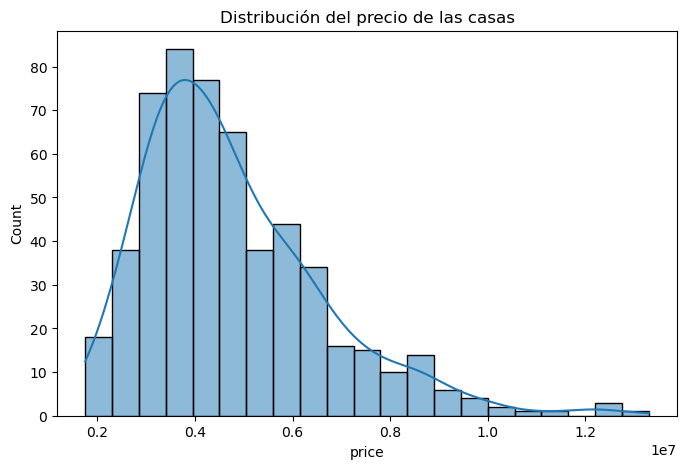

In [8]:
#EDA-Distribución del precio
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True)
plt.title("Distribución del precio de las casas")
plt.show()

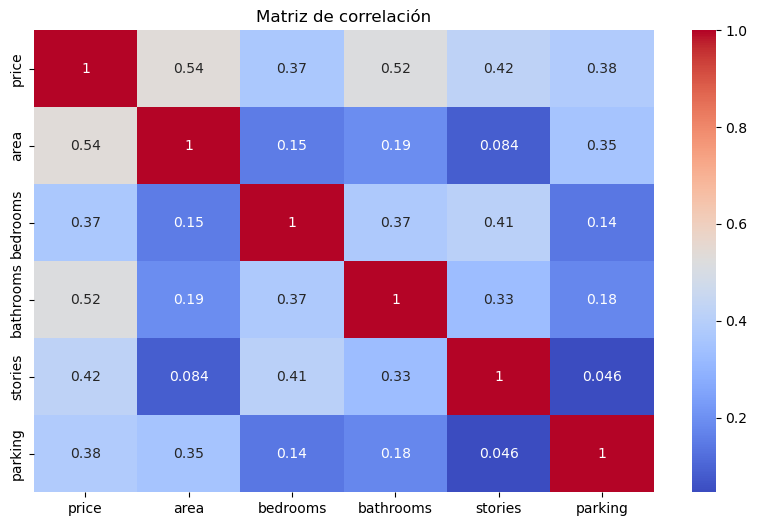

In [9]:
#EDA-Correlación
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

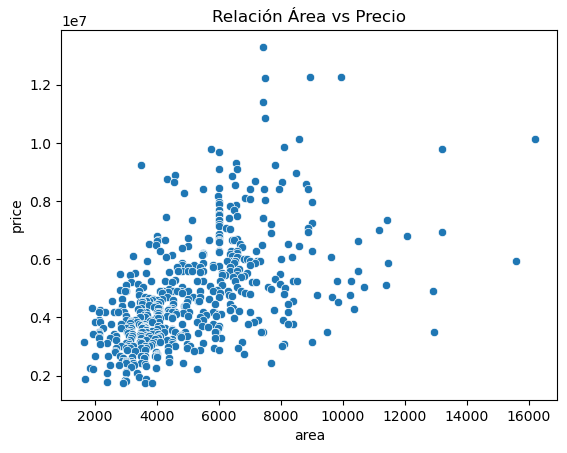

In [10]:
#Análisis Bivariado-Precio Área
sns.scatterplot(x='area', y='price', data=df)
plt.title("Relación Área vs Precio")
plt.show()

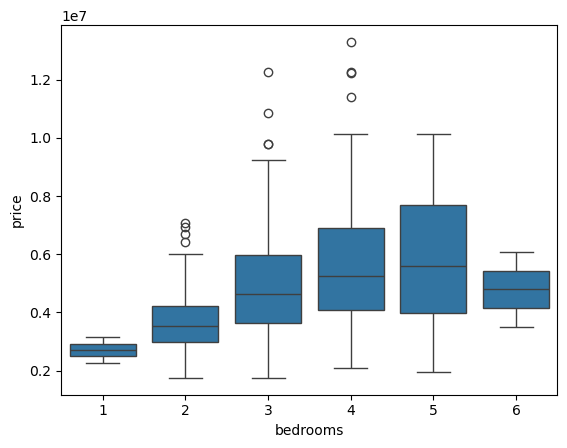

In [11]:
#Análisis Bivariado-Por número de habitaciones
sns.boxplot(x='bedrooms', y='price', data=df)
plt.show()

In [12]:
#ML
#Variables categóricas
#mainroad
#guestroom
#basement
#hotwaterheating
#airconditioning
#prefarea
#furnishingstatus

In [13]:
#ML-Conversión de variables
df = pd.get_dummies(df, drop_first=True)

In [14]:
#ML-Creación de variable
df['area_per_room'] = df['area'] / df['bedrooms']

In [15]:
#Separación de variables dependientes e independientes
X = df.drop('price', axis=1)

y = df['price']

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [17]:
#División-Train Test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(381, 14)
(164, 14)


In [18]:
#Modelo de regresión lineal
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [19]:
#Predicciones
y_pred = model.predict(X_test)

In [20]:
#Evaluación del modelo
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 1521648847320.7158


In [21]:
#R2
r2 = r2_score(y_test, y_pred)
print("R2:", r2)

R2: 0.6466533641708414


In [23]:
#Importancia de variables
coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_
})

coefficients = coefficients.sort_values(by='Coeficiente', ascending=False)

print(coefficients)

                           Variable    Coeficiente
0                              area  831345.137428
2                         bathrooms  552590.167444
3                           stories  349745.723099
9               airconditioning_yes  320676.873785
4                           parking  258743.841691
7                      basement_yes  232689.484507
10                     prefarea_yes  209236.129379
5                      mainroad_yes  136217.047507
8               hotwaterheating_yes  132995.171669
6                     guestroom_yes   97350.677625
11  furnishingstatus_semi-furnished  -69063.965989
1                          bedrooms -101539.553661
12     furnishingstatus_unfurnished -195278.209422
13                    area_per_room -314179.823533


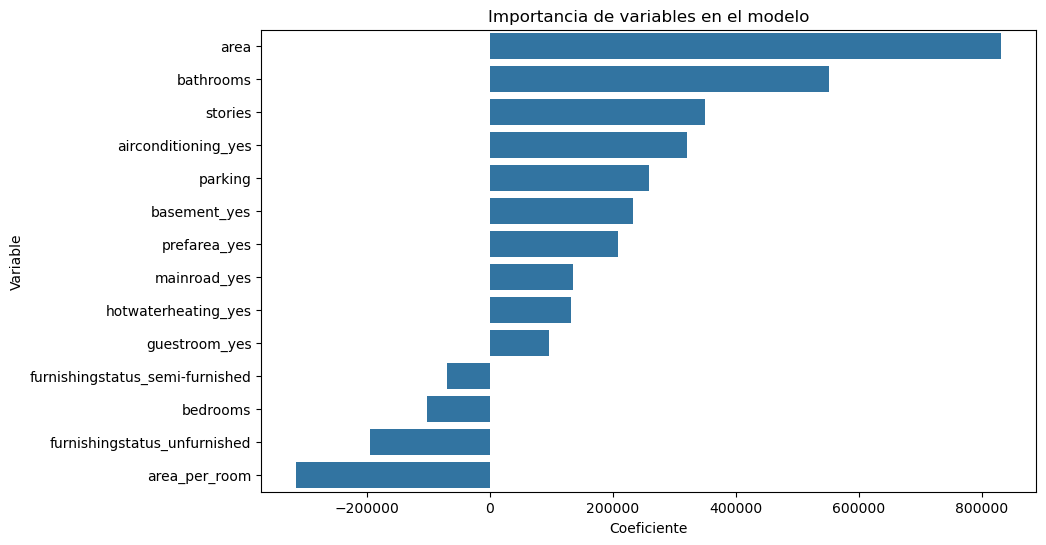

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Coeficiente',
    y='Variable',
    data=coefficients
)

plt.title("Importancia de variables en el modelo")
plt.show()

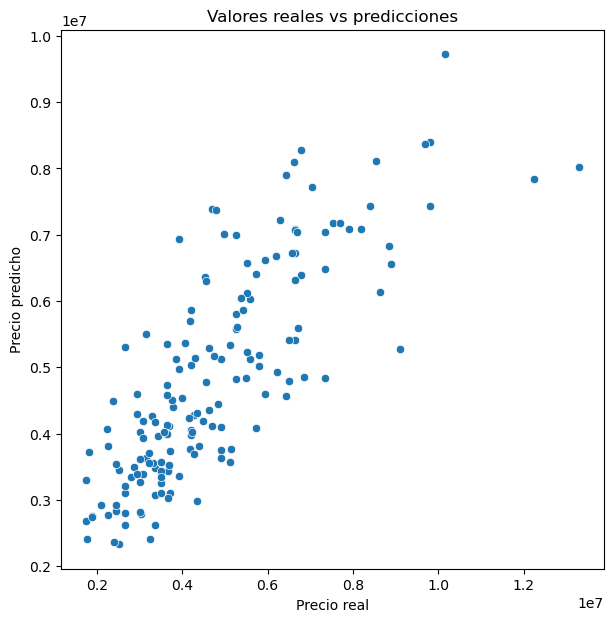

In [25]:
#Visualización final
plt.figure(figsize=(7,7))

sns.scatterplot(x=y_test, y=y_pred)

plt.xlabel("Precio real")
plt.ylabel("Precio predicho")

plt.title("Valores reales vs predicciones")

plt.show()

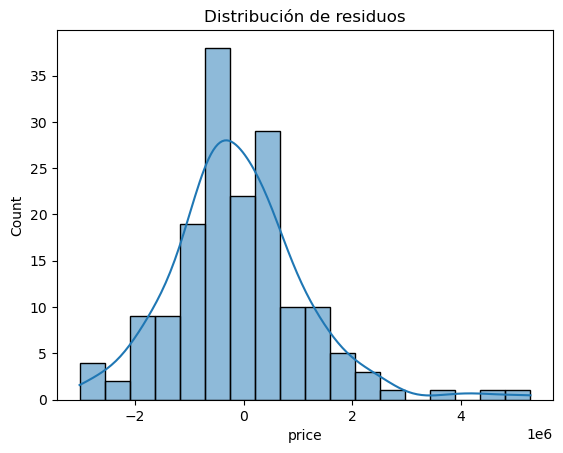

In [26]:
#Distribución de errores
residuals = y_test - y_pred

sns.histplot(residuals, kde=True)

plt.title("Distribución de residuos")

plt.show()

In [27]:
#Ejemplo de predicción
example = X_test.iloc[[0]]

prediction = model.predict(example)

print("Precio estimado:", prediction)

Precio estimado: [5374157.4633868]
